# Medical Text Adaptation
**DAT5565 - Group 21**

We compare Qwen3.5-2B-Base, CPT, CPT+SFT, and an LSTM trained on medical question-answer pairs.

The main sections show the data, models, and results. The appendix contains optional commands for rerunning the experiments. Run All checks saved files and recreates the tables and plots; it does not start training or inference.

To run this notebook, install `requirements-notebook.txt` and open it from the project root. Saved outputs can be read without the data or model weights.

## 1. Setup

Load the analysis tools and select which operations to run. Keep all switches off to view the saved results.

The display helpers are collapsed below. Expand that cell if you want to inspect the table formatting or command runner.

In [1]:
# Set up the analysis environment.
from pathlib import Path
import html
import json
import math
import subprocess
import sys
from statistics import mean
import matplotlib.pyplot as plt
from IPython.display import HTML, display

ROOT = Path.cwd().resolve()
if not (ROOT / "src/healthcpt").is_dir():
    raise FileNotFoundError("Start the notebook from the project root")
sys.path.insert(0, str(ROOT / "src"))
from healthcpt.qa_metrics import calculate_metrics, file_sha256, read_examples, select_examples
from healthcpt.sft import _qa_texts
from healthcpt.lstm_baseline import training_text

RUN_DATA_PREPARATION = False
RUN_TRAINING = False
RUN_EXPORT = False
RUN_INFERENCE = False
RUN_BERTSCORE = False
REPRO = ROOT / "runs/notebook_reproduction"

plt.rcParams.update({"figure.dpi": 110, "font.size": 10, "axes.spines.top": False,
                     "axes.spines.right": False, "axes.grid": True, "grid.alpha": 0.2})
print("Python:", sys.version.split()[0])
print("Default mode: saved-result analysis")
print("Enabled operations:", [name for name, enabled in [("data", RUN_DATA_PREPARATION), ("training", RUN_TRAINING), ("export", RUN_EXPORT), ("inference", RUN_INFERENCE), ("BERTScore", RUN_BERTSCORE)] if enabled])

Python: 3.12.13
Default mode: saved-result analysis
Enabled operations: []


In [2]:
# Display and command helpers. Expand this cell to view them.
def load_json(relative):
    return json.loads((ROOT / relative).read_text(encoding="utf-8"))

def load_rows(relative):
    return [json.loads(line) for line in (ROOT / relative).read_text(encoding="utf-8").splitlines() if line.strip()]

def table(headers, rows):
    def escape(value): return html.escape(str(value))
    base = "color:inherit !important;text-align:left;padding:8px 12px;border-bottom:1px solid currentColor;"
    header = base + "background:transparent !important;"
    body_style = base + "background:transparent !important;"
    head = "".join(f'<th scope="col" style="{header}">{escape(h)}</th>' for h in headers)
    body = "".join("<tr>" + "".join(f'<td style="{body_style}">{escape(v)}</td>' for v in row) + "</tr>" for row in rows)
    display(HTML(f'<div style="background:transparent !important;color:inherit !important;display:inline-block;max-width:100%;overflow-x:auto;">'
                 f'<table style="border-collapse:collapse;background:transparent !important;color:inherit !important;">'
                 f'<thead><tr>{head}</tr></thead><tbody>{body}</tbody></table></div>'))

def run_step(command, enabled):
    command = [str(arg) for arg in command]
    name = command[3] if command[:3] == ["uv", "run", "healthcpt"] else Path(command[1]).name
    if enabled:
        print("Running:", name)
        subprocess.run(command, cwd=ROOT, check=True)
    else:
        print("Skipped (disabled):", name)


## 2. Data

MedQuAD provides question-answer pairs. CPT also uses MedlinePlus summaries and licensed PMC articles. We split MedQuAD by source URL and remove specified overlaps from evaluation files.

The next cell counts the data rows and shows their sources and licenses.

In [3]:
# Count the prepared data and read the cleaning manifest.
DATA_FILES = {
    "CPT train": "data/processed/cpt-medical-v3/cpt_train.jsonl",
    "CPT validation": "data/processed/cpt-medical-v3/cpt_validation.jsonl",
    "QA train": "data/processed/medquad-v1/qa_train.jsonl",
    "QA validation": "data/processed/cpt-medical-v3/qa_validation_eval.jsonl",
    "QA test": "data/processed/cpt-medical-v3/qa_test_eval.jsonl",
}
counts = {}
for name, relative in DATA_FILES.items():
    with (ROOT / relative).open(encoding="utf-8") as handle:
        counts[name] = sum(bool(line.strip()) for line in handle)
table(["Dataset", "Rows"], list(counts.items()))
manifest = load_json("data/processed/cpt-medical-v3/manifest.json")
table(["CPT source", "Train chunks"], list(manifest["cpt_train"]["records_by_source"].items()))
table(["License", "Train chunks"], list(manifest["cpt_train"]["licenses"].items()))
table(["QA split", "Before", "After", "Removed"],
      [[split, manifest[key]["before"], manifest[key]["after"], sum(manifest[key]["removed"].values())]
       for split, key in [("Validation", "qa_validation_rows"), ("Test", "qa_test_rows")]])

Dataset,Rows
CPT train,24240
CPT validation,1645
QA train,12799
QA validation,1471
QA test,1573


CPT source,Train chunks
CancerGov,935
GARD,3152
GHR,2420
MPlusHealthTopics,422
NIDDK,688
NINDS,482
NIHSeniorHealth,508
NHLBI,568
CDC,189
MedlinePlus,1758


License,Train chunks
CC BY 4.0 (MedQuAD dataset; retain source attribution),9364
Public domain health-topic summary; cite MedlinePlus/NLM,1758
CC BY,13109
CC0,9


QA split,Before,After,Removed
Validation,1713,1471,242
Test,1847,1573,274


## 3. Models

**Qwen:** CPT trains the Base model on medical text. SFT continues from the CPT adapter using question-answer pairs. Both stages use TensorFlow, KerasHub, and rank-8 LoRA. The SFT loss includes both question and answer tokens, excluding padding.

**LSTM:** A training-only vocabulary feeds an embedding layer, a forward LSTM, dropout, and a vocabulary output layer. The model predicts the next word.

The next cell shows how a training example is formatted. The code excerpts after it are for reference; they are not executable notebook cells.

In [4]:
# Show one training example and its next-word targets.
train_path = ROOT / DATA_FILES["QA train"]
example = read_examples(train_path)[0]
sft_example = _qa_texts(train_path, 1)[0]
lstm_example = training_text(example)
table(["Input", "Text"], [
    ["Question", example["question"]],
    ["SFT text (first 400 characters)", sft_example[:400]],
    ["LSTM text (first 400 characters)", lstm_example[:400]],
])
# Demonstrate the one-word shift using the actual saved LSTM vocabulary.
vocabulary = load_json("runs/lstm_qa_50epochs/vocabulary.json")
word_ids = {word: index for index, word in enumerate(vocabulary)}
tokens = [word_ids.get(word, 1) for word in lstm_example.lower().split()]
table(["Position", "Input word", "Target next word"],
      [[i, vocabulary[tokens[i]], vocabulary[tokens[i + 1]]] for i in range(min(8, len(tokens) - 1))])
print("Vocabulary size:", len(vocabulary))

Input,Text
Question,What is (are) Adult Acute Lymphoblastic Leukemia ?
SFT text (first 400 characters),"Question: What is (are) Adult Acute Lymphoblastic Leukemia ? Answer: Key Points - Adult acute lymphoblastic leukemia (ALL) is a type of cancer in which the bone marrow makes too many lymphocytes (a type of white blood cell). - Leukemia may affect red blood cells, white blood cells, and platelets. - Previous chemotherapy and exposure to radiation may increase the risk of developing ALL. - Signs and"
LSTM text (first 400 characters),"Question: What is (are) Adult Acute Lymphoblastic Leukemia ? Answer: Key Points - Adult acute lymphoblastic leukemia (ALL) is a type of cancer in which the bone marrow makes too many lymphocytes (a type of white blood cell). - Leukemia may affect red blood cells, white blood cells, and platelets. - Previous chemotherapy and exposure to radiation may increase the risk of developing ALL. - Signs and"


Position,Input word,Target next word
0,question:,what
1,what,is
2,is,(are)
3,(are),adult
4,adult,acute
5,acute,lymphoblastic
6,lymphoblastic,leukemia
7,leukemia,?


Vocabulary size: 20000


### CPT implementation

Load the language model and enable LoRA. Source: `src/healthcpt/cpt.py`.

```python
preprocessor = keras_hub.models.CausalLMPreprocessor.from_preset(
    preset, sequence_length=sequence_length
)
if _is_qwen3_5_preset(preset):
    backbone = keras_hub.models.Qwen3_5Backbone.from_preset(
        preset, vision_encoder=None
    )
    model = keras_hub.models.Qwen3_5CausalLM(
        backbone=backbone, preprocessor=preprocessor
    )
else:
    model = keras_hub.models.CausalLM.from_preset(
        preset, preprocessor=preprocessor
    )
if lora_rank:
    # LoRA trains a small set of adapter weights while freezing the base model.
    model.backbone.enable_lora(rank=lora_rank)
```

### SFT implementation

Load the model and the CPT adapter before fine-tuning. Source: `src/healthcpt/sft.py`.

```python
preprocessor = keras_hub.models.CausalLMPreprocessor.from_preset(
    preset, sequence_length=sequence_length
)
backbone = keras_hub.models.Qwen3_5Backbone.from_preset(
    preset, vision_encoder=None
)
model = keras_hub.models.Qwen3_5CausalLM(
    backbone=backbone, preprocessor=preprocessor
)
model.backbone.enable_lora(rank=lora_rank)
model.backbone.load_lora_weights(str(cpt_adapter_path))
```

### LSTM implementation

Build the layers and define the next-word loss. Source: `src/healthcpt/lstm_baseline.py`.

```python
inputs = keras.Input(shape=(None,), dtype="int64", name="tokens")
embedded = keras.layers.Embedding(
    len(vocabulary), args.embedding_dim, mask_zero=True, name="embedding",
)(inputs)
# A single forward LSTM cannot look at future answer words.
sequence, _, _ = keras.layers.LSTM(
    args.hidden_size, return_sequences=True, return_state=True, name="lstm",
)(embedded)
sequence = keras.layers.Dropout(0.2)(sequence)
logits = keras.layers.Dense(len(vocabulary), name="word_logits")(sequence)
model = keras.Model(inputs, logits, name="medical_lstm")
model.compile(
    optimizer=keras.optimizers.Adam(args.learning_rate, clipnorm=1.0),
    loss=keras.losses.SparseCategoricalCrossentropy(
        from_logits=True, reduction="mean_with_sample_weight",
    ),
    weighted_metrics=[keras.metrics.SparseCategoricalAccuracy(name="token_accuracy")],
    jit_compile=False,
)
```

## 4. Training settings

These settings come from the completed runs. SFT and LSTM share 12,799 training pairs and 1,471 validation pairs. LSTM ran for 16 epochs and selected epoch 14 by validation loss.

In [5]:
# Read the completed training records.
training = {stage: load_json(f"runs/{folder}/run.json") for stage, folder in [
    ("CPT", "qwen3_5_2b_cpt_full_1epoch"), ("SFT", "qwen3_5_2b_sft_full_1epoch"), ("LSTM", "lstm_qa_50epochs")]}
table(["Stage", "Train rows", "Validation rows", "Sequence length", "Batch", "LR", "Epochs"], [
    [name, r.get("train_examples", r.get("train_documents")), r.get("validation_examples", r.get("validation_documents")),
     r["sequence_length"], r["batch_size"], r["learning_rate"], r.get("completed_epochs", r.get("epochs"))]
    for name, r in training.items()])
table(["Stage", "TensorFlow", "Keras", "LoRA rank / Parameters"], [
    [name, r["tensorflow"], r["keras"], r.get("lora_rank", r.get("parameters"))] for name, r in training.items()])
assert file_sha256(ROOT / DATA_FILES["QA train"]) == training["LSTM"]["train_file_sha256"]
assert file_sha256(ROOT / DATA_FILES["QA validation"]) == training["LSTM"]["validation_file_sha256"]
print("LSTM training/validation data hashes verified")

Stage,Train rows,Validation rows,Sequence length,Batch,LR,Epochs
CPT,24240,1645,512,1,0.0001,1
SFT,12799,1471,512,1,2e-05,1
LSTM,12799,1471,512,8,0.001,16


Stage,TensorFlow,Keras,LoRA rank / Parameters
CPT,2.21.0,3.15.1,8
SFT,2.21.0,3.15.1,8
LSTM,2.21.0,3.15.1,8094240


LSTM training/validation data hashes verified


## 5. Training curves

Plot loss and token accuracy for each stage. CPT and SFT use running TensorBoard metrics. LSTM shows all 16 training and validation epochs. The table reports the selected checkpoint values.

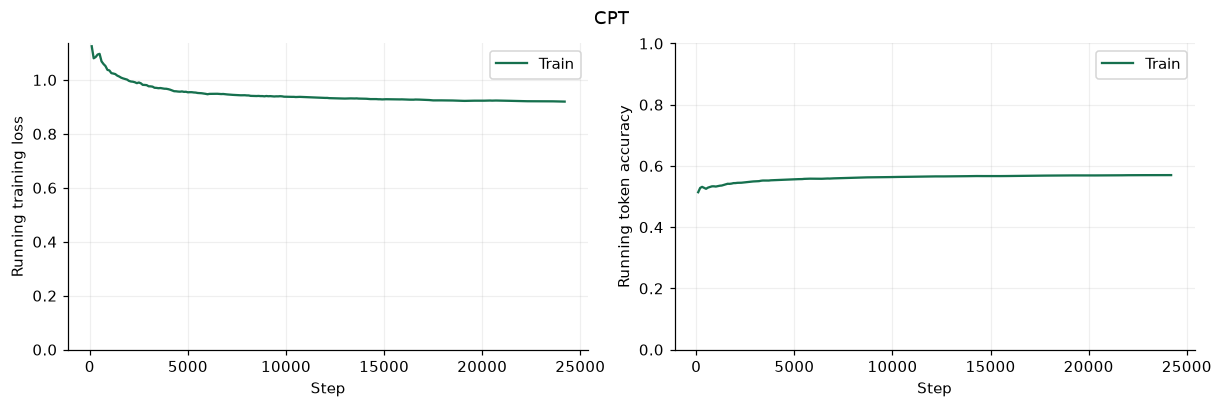

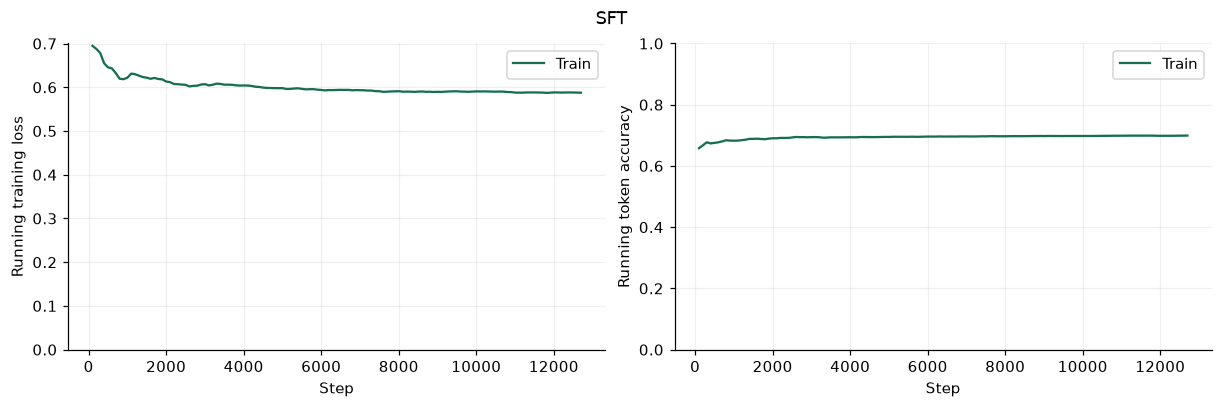

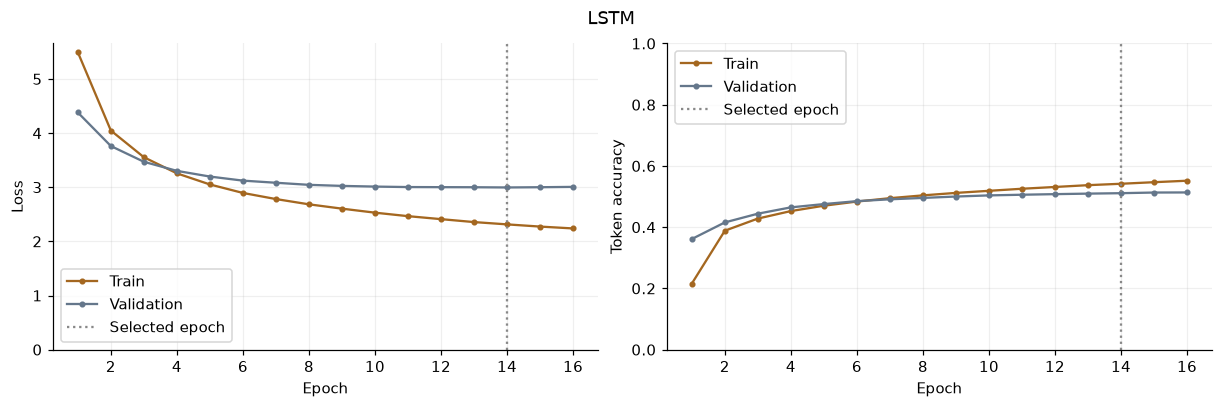

Stage,Epoch,Train loss,Val loss,Train token accuracy,Val token accuracy
CPT,1,0.9197,1.2288,0.5700,0.5382
SFT,1,0.5879,0.6134,0.6993,0.7025
LSTM,14,2.3138,2.9958,0.5418,0.5110


In [6]:
# Draw training curves from saved records.
curves = load_json("runs/training_curves.json")
for stage in ("cpt", "sft"):
    for source in curves[stage]["sources"]:
        assert file_sha256(ROOT / source["path"]) == source["sha256"]
hist = training["LSTM"]["history"]
for stage in ("CPT", "SFT", "LSTM"):
    fig, axes = plt.subplots(1, 2, figsize=(11, 3.6), layout="constrained")
    if stage == "LSTM":
        x = range(1, len(hist["loss"]) + 1)
        for ax, key, validation_key, label in zip(axes, ["loss", "token_accuracy"], ["val_loss", "val_token_accuracy"], ["Loss", "Token accuracy"]):
            ax.plot(x, hist[key], label="Train", color="#a46720", marker=".")
            ax.plot(x, hist[validation_key], label="Validation", color="#65778b", marker=".")
            ax.axvline(training["LSTM"]["selected_epoch"], color="#888888", linestyle=":", label="Selected epoch")
            ax.set(xlabel="Epoch", ylabel=label, ylim=(0, 1 if key == "token_accuracy" else None))
            ax.legend()
    else:
        for ax, key, label in zip(axes, ["loss", "accuracy"], ["Running training loss", "Running token accuracy"]):
            points = curves[stage.lower()][key]
            ax.plot([p[0] for p in points], [p[1] for p in points], color="#16704e", label="Train")
            ax.set(xlabel="Step", ylabel=label, ylim=(0, 1 if key == "accuracy" else None))
            ax.legend()
    fig.suptitle(stage)
    plt.show()
    plt.close(fig)
rows = []
for name, record in training.items():
    index = record["selected_epoch"] - 1 if name == "LSTM" else 0
    h = record["history"]
    accuracy = "token_accuracy" if name == "LSTM" else "sparse_categorical_accuracy"
    rows.append([name, index + 1, *[f"{h[k][index]:.4f}" for k in ["loss", "val_loss", accuracy, "val_" + accuracy]]])
table(["Stage", "Epoch", "Train loss", "Val loss", "Train token accuracy", "Val token accuracy"], rows)

## 6. Evaluation checks

QA uses 200 test questions sampled with seed 5565. Qwen generates up to 128 subword tokens; LSTM generates up to 128 words. MMLU uses all 272 professional_medicine questions with five dev examples and next-token scoring for A/B/C/D.

The next cell checks question alignment, file hashes, and BERTScore settings. Base and CPT+SFT use the latest Infra run. CPT uses an earlier run with identical Base answers.

In [7]:
# Check that all QA runs use the same sample and references.
PATHS = {
    "Qwen Infra": "runs/qa_eval_cpt_sft_test_200_infra",
    "CPT": "runs/qa_eval_cpt_test_200",
    "LSTM": "runs/qa_eval_lstm_16epoch_test_200",
    "LSTM BERTScore": "runs/qa_eval_lstm_16epoch_test_200_bertscore",
    "MMLU": "runs/mmlu_professional_medicine_5shot",
}
reports = {name: load_json(path + "/metrics.json") for name, path in PATHS.items()}
predictions = {name: load_rows(PATHS[name] + "/predictions.jsonl") for name in ["Qwen Infra", "CPT", "LSTM", "LSTM BERTScore"]}
sample = select_examples(read_examples(ROOT / DATA_FILES["QA test"]), 200, 5565)
for name in predictions:
    assert len(predictions[name]) == len(sample) == reports[name]["evaluation_examples"]
    assert reports[name]["evaluation_file_sha256"] == file_sha256(ROOT / DATA_FILES["QA test"])
    assert all(all(row[k] == expected[k] for k in ["source_line", "question", "reference_answer"])
               for row, expected in zip(predictions[name], sample, strict=True))
assert all(old["base_prediction"] == new["base_prediction"] for old, new in zip(predictions["CPT"], predictions["Qwen Infra"], strict=True))
assert reports["LSTM BERTScore"]["source_predictions_sha256"] == file_sha256(ROOT / PATHS["LSTM"] / "predictions.jsonl")
assert reports["LSTM BERTScore"]["qwen_metrics_sha256"] == file_sha256(ROOT / PATHS["Qwen Infra"] / "metrics.json")
assert reports["LSTM BERTScore"]["bertscore"] == reports["Qwen Infra"]["metrics"]["bertscore"]
assert all(a["candidate_prediction"] == b["candidate_prediction"] for a, b in zip(predictions["LSTM"], predictions["LSTM BERTScore"], strict=True))
print("PASS: sample, references, data hashes, Base answers and BERTScore provenance")
table(["BERTScore setting", "Value"], list(reports["Qwen Infra"]["metrics"]["bertscore"].items()))

PASS: sample, references, data hashes, Base answers and BERTScore provenance


BERTScore setting,Value
model_type,roberta-large
language,en
rescale_with_baseline,False
package_version,0.3.13
hash,roberta-large_L17_no-idf_version=0.3.12(hug_trans=5.17.0)


## 7. Medical QA results

Recalculate Exact Match, Token F1, and ROUGE-L, then check the saved BERTScore values. A dash means the metric was not measured.

Model,EM,Token F1,ROUGE-L F1,BERTScore F1,Empty answers
Base,0.0000,0.2540,0.1582,0.8378,0
CPT,0.0000,0.2332,0.1638,—,0
CPT+SFT,0.0000,0.3269,0.2646,0.8611,0
LSTM,0.0000,0.2525,0.2067,0.8253,0


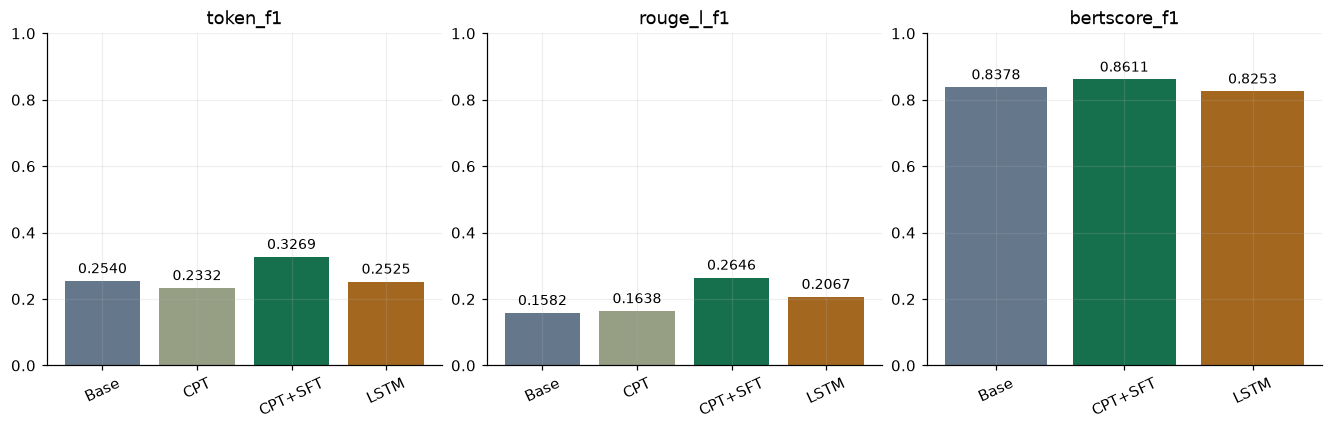

In [8]:
# Recalculate the QA metrics and plot the comparison.
references = [row["reference_answer"] for row in sample]
MODEL_OUTPUTS = {
    "Base": [r["base_prediction"] for r in predictions["Qwen Infra"]],
    "CPT": [r["candidate_prediction"] for r in predictions["CPT"]],
    "CPT+SFT": [r["candidate_prediction"] for r in predictions["Qwen Infra"]],
    "LSTM": [r["candidate_prediction"] for r in predictions["LSTM"]],
}
saved_metrics = {"Base": reports["Qwen Infra"]["metrics"]["base"], "CPT": reports["CPT"]["metrics"]["candidate"],
                 "CPT+SFT": reports["Qwen Infra"]["metrics"]["candidate"], "LSTM": reports["LSTM BERTScore"]["metrics"]["LSTM"]}
qa_metrics = {}
for name, answers in MODEL_OUTPUTS.items():
    qa_metrics[name] = calculate_metrics(answers, references)
    for key, value in qa_metrics[name].items():
        assert math.isclose(value, saved_metrics[name][key], abs_tol=1e-12), (name, key)
    if "bertscore_f1" in saved_metrics[name]:
        field = "candidate_bertscore_f1" if name == "LSTM" else ("base_bertscore_f1" if name == "Base" else "candidate_bertscore_f1")
        source = predictions["LSTM BERTScore"] if name == "LSTM" else predictions["Qwen Infra"]
        values = [row[field] for row in source]
        assert len(values) == 200 and all(math.isfinite(v) for v in values)
        assert math.isclose(mean(values), saved_metrics[name]["bertscore_f1"], abs_tol=1e-12)
        qa_metrics[name]["bertscore_f1"] = mean(values)
table(["Model", "EM", "Token F1", "ROUGE-L F1", "BERTScore F1", "Empty answers"], [
    [name, f"{m['normalized_exact_match']:.4f}", f"{m['token_f1']:.4f}", f"{m['rouge_l_f1']:.4f}",
     f"{m['bertscore_f1']:.4f}" if "bertscore_f1" in m else "—", m["empty_predictions"]]
    for name, m in qa_metrics.items()])
fig, axes = plt.subplots(1, 3, figsize=(12, 3.8), layout="constrained")
colors = {"Base": "#65778b", "CPT": "#969f84", "CPT+SFT": "#16704e", "LSTM": "#a46720"}
for ax, metric in zip(axes, ["token_f1", "rouge_l_f1", "bertscore_f1"]):
    names = [name for name, m in qa_metrics.items() if metric in m]
    values = [qa_metrics[name][metric] for name in names]
    bars = ax.bar(names, values, color=[colors[name] for name in names])
    ax.bar_label(bars, fmt="%.4f", padding=3, fontsize=9)
    ax.set(title=metric, ylim=(0, 1))
    ax.tick_params(axis="x", labelrotation=25)
plt.show()
plt.close(fig)

## 8. MMLU results

Recalculate accuracy and compare which questions each model answered correctly. Recorded elapsed times are not used as a speed benchmark.

Model,Correct / Total,Accuracy,Recorded elapsed seconds
Base,165/272,60.66%,19.8591
CPT+SFT,170/272,62.50%,12.7581


Paired outcome,Questions
Both correct,149
CPT+SFT only correct,21
Base only correct,16
Both incorrect,86


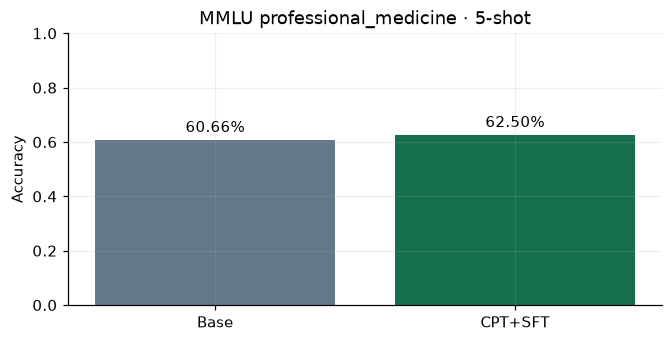

In [9]:
# Recalculate MMLU accuracy and paired outcomes.
mmlu = reports["MMLU"]
base = load_rows(PATHS["MMLU"] + "/base_predictions.jsonl")
candidate = load_rows(PATHS["MMLU"] + "/candidate_predictions.jsonl")
assert len(base) == len(candidate) == mmlu["examples"] == 272
assert len({r["id"] for r in base}) == len({r["id"] for r in candidate}) == 272
assert all(all(a[k] == b[k] for k in ["id", "question", "choices", "gold"]) for a, b in zip(base, candidate, strict=True))
for key, rows in [("base", base), ("candidate", candidate)]:
    assert all(row["correct"] == (row["prediction"] == row["gold"]) for row in rows)
    correct = sum(row["correct"] for row in rows)
    assert correct == mmlu["models"][key]["correct"]
    assert math.isclose(correct / len(rows), mmlu["models"][key]["accuracy"], abs_tol=1e-12)
paired = {"both_correct": sum(a["correct"] and b["correct"] for a, b in zip(base, candidate)),
          "candidate_only_correct": sum(not a["correct"] and b["correct"] for a, b in zip(base, candidate)),
          "base_only_correct": sum(a["correct"] and not b["correct"] for a, b in zip(base, candidate)),
          "both_wrong": sum(not a["correct"] and not b["correct"] for a, b in zip(base, candidate))}
assert paired == mmlu["paired_counts"]
table(["Model", "Correct / Total", "Accuracy", "Recorded elapsed seconds"],
      [[r["name"], f"{r['correct']}/272", f"{r['accuracy']:.2%}", f"{r['elapsed_seconds']:.4f}"] for r in mmlu["models"].values()])
labels = {"both_correct": "Both correct", "candidate_only_correct": "CPT+SFT only correct",
          "base_only_correct": "Base only correct", "both_wrong": "Both incorrect"}
table(["Paired outcome", "Questions"], [[labels[key], value] for key, value in paired.items()])
fig, ax = plt.subplots(figsize=(6, 3), layout="constrained")
bars = ax.bar(["Base", "CPT+SFT"], [mmlu["models"][k]["accuracy"] for k in ["base", "candidate"]], color=[colors["Base"], colors["CPT+SFT"]])
ax.bar_label(bars, labels=[f"{mmlu['models'][k]['accuracy']:.2%}" for k in ["base", "candidate"]], padding=3)
ax.set(ylim=(0, 1), ylabel="Accuracy", title="MMLU professional_medicine · 5-shot")
plt.show()
plt.close(fig)

## 9. Inference resources

Qwen runs used an RTX 4090, batch size 1, and three warm-up questions. Latency excludes loading and warm-up. GPU memory excludes BERTScore.

CPT+SFT generates shorter answers, which affects mean latency. LSTM timing is shown separately because it counts words rather than Qwen tokens.

In [10]:
# Display the recorded inference measurements.
infra = reports["Qwen Infra"]["infrastructure"]
measurements = [
    ("Load seconds", lambda m: m["model_load_seconds"]),
    ("Mean latency seconds", lambda m: m["request_latency_seconds"]["mean"]),
    ("Median latency seconds", lambda m: m["request_latency_seconds"]["median"]),
    ("P95 latency seconds", lambda m: m["request_latency_seconds"]["p95_nearest_rank"]),
    ("Generation tokens/second", lambda m: m["output_tokens_per_second"]),
    ("Mean output token IDs", lambda m: m["average_output_token_ids"]),
    ("Total output token IDs", lambda m: m["generated_token_ids"]),
    ("Peak allocated MiB", lambda m: m["gpu_memory_mib"]["peak_allocated"]),
    ("Peak reserved MiB", lambda m: m["gpu_memory_mib"]["peak_reserved"]),
    ("Model folder bytes", lambda m: m["model_files_size_bytes"]),
]
table(["Metric", "Base", "CPT+SFT"], [[name, fn(infra["base"]), fn(infra["candidate"])] for name, fn in measurements])
lstm = reports["LSTM"]
table(["LSTM metric", "Value"], [["Mean answer seconds", lstm["average_seconds_per_answer"]],
      ["Mean generated words", lstm["average_generated_words"]], ["Parameters", training["LSTM"]["parameters"]],
      ["Validation word perplexity", training["LSTM"]["validation_word_perplexity"]],
      ["Training + validation + save seconds", training["LSTM"]["training_seconds_including_validation_and_saves"]]])

Metric,Base,CPT+SFT
Load seconds,11.4075,10.0868
Mean latency seconds,3.5803,3.3414
Median latency seconds,3.5995,3.5867
P95 latency seconds,3.6273,3.6378
Generation tokens/second,35.5645,35.6234
Mean output token IDs,127.29,119.0
Total output token IDs,25458,23799
Peak allocated MiB,4252.7,4253.08
Peak reserved MiB,4364.0,4344.0
Model folder bytes,4571206192,4571206295


LSTM metric,Value
Mean answer seconds,0.12423892221180723
Mean generated words,86.115
Parameters,8094240
Validation word perplexity,18.35596471021939
Training + validation + save seconds,1778.1969653158449


## 10. Answer examples

Show the first three questions in the fixed sample. These are for human review and were not chosen by score.

In [11]:
# Show saved answers for the first three sample questions.
for index in range(3):
    display(HTML(f"""<h4 style="color:inherit !important;background:transparent !important;padding:10px 12px;margin:12px 0 0;">Source line {sample[index]['source_line']}: {html.escape(sample[index]['question'])}</h4>"""))
    table(["Source", "Answer"], [["Reference", references[index]]] +
          [[name, answers[index]] for name, answers in MODEL_OUTPUTS.items()])

Source,Answer
Reference,"Tests that examine the blood and bone marrow are used to detect (find) and diagnose childhood ALL. The following tests and procedures may be used to diagnose childhood ALL and find out if leukemia cells have spread to other parts of the body such as the brain or testicles: - Physical exam and history : An exam of the body to check general signs of health, including checking for signs of disease, such as lumps or anything else that seems unusual. A history of the patient's health habits and past illnesses and treatments will also be taken. - Complete blood count (CBC) with differential : A procedure in which a sample of blood is drawn and checked for the following: - The number of red blood cells and platelets. - The number and type of white blood cells. - The amount of hemoglobin (the protein that carries oxygen) in the red blood cells. - The portion of the sample made up of red blood cells. - Blood chemistry studies : A procedure in which a blood sample is checked to measure the amounts of certain substances released into the blood by organs and tissues in the body. An unusual (higher or lower than normal) amount of a substance can be a sign of disease. - Bone marrow aspiration and biopsy : The removal of bone marrow and a small piece of bone by inserting a hollow needle into the hipbone or breastbone. A pathologist views the bone marrow and bone under a microscope to look for signs of cancer. The following tests are done on blood or the bone marrow tissue that is removed: - Cytogenetic analysis : A laboratory test in which the cells in a sample of blood or bone marrow are viewed under a microscope to look for certain changes in the chromosomes of lymphocytes. For example, in Philadelphia chromosome positive ALL, part of one chromosome switches places with part of another chromosome. This is called the Philadelphia chromosome. - Immunophenotyping : A laboratory test in which the antigens or markers on the surface of a blood or bone marrow cell are checked to see if they are lymphocytes or myeloid cells. If the cells are malignant lymphocytes (cancer) they are checked to see if they are B lymphocytes or T lymphocytes. - Lumbar puncture : A procedure used to collect a sample of cerebrospinal fluid (CSF) from the spinal column. This is done by placing a needle between two bones in the spine and into the CSF around the spinal cord and removing a sample of the fluid. The sample of CSF is checked under a microscope for signs that leukemia cells have spread to the brain and spinal cord. This procedure is also called an LP or spinal tap. This procedure is done after leukemia is diagnosed to find out if leukemia cells have spread to the brain and spinal cord. Intrathecal chemotherapy is given after the sample of fluid is removed to treat any leukemia cells that may have spread to the brain and spinal cord. - Chest x-ray : An x-ray of the organs and bones inside the chest. An x-ray is a type of energy beam that can go through the body and onto film, making a picture of areas inside the body. The chest x-ray is done to see if leukemia cells have formed a mass in the middle of the chest."
Base,Childhood acute lymphoblastic leukemia (ALL) is a cancer of the blood and bone marrow. It is the most common type of leukemia in children. The diagnosis of ALL is made by a combination of tests. These tests include: Blood tests: These tests are used to check the number of white blood cells in the blood. Bone marrow biopsy: This test is used to check the number of white blood cells in the bone marrow. Cytogenetic analysis: This test is used to check the chromosomes in the bone marrow. Flow cytometry: This test is used to check the cells in the blood.
CPT,"Diagnosis of childhood acute lymphoblastic leukemia (ALL) is based on a combination of clinical findings, laboratory tests, and imaging studies. The following are the most common tests used to diagnose ALL: - Blood tests to check for the presence of leukemia cells in the bl

Source,Answer
Reference,"New types of treatment are being tested in clinical trials. This summary section describes treatments that are being studied in clinical trials. It may not mention every new treatment being studied. Information about clinical trials is available from the NCI website. Chimeric antigen receptor (CAR) T-cell therapy CAR T-cell therapy is a type of immunotherapy that changes the patient's T cells (a type of immune system cell) so they will attack certain proteins on the surface of cancer cells. T cells are taken from the patient and special receptors are added to their surface in the laboratory. The changed cells are called chimeric antigen receptor (CAR) T cells. The CAR T cells are grown in the laboratory and given to the patient by infusion. The CAR T cells multiply in the patient's blood and attack cancer cells. CAR T-cell therapy is being studied in the treatment of childhood ALL that has relapsed (come back) a second time. Patients may want to think about taking part in a clinical trial. For some patients, taking part in a clinical trial may be the best treatment choice. Clinical trials are part of the cancer research process. Clinical trials are done to find out if new cancer treatments are safe and effective or better than the standard treatment. Many of today's standard treatments for cancer are based on earlier clinical trials. Patients who take part in a clinical trial may receive the standard treatment or be among the first to receive a new treatment. Patients who take part in clinical trials also help improve the way cancer will be treated in the future. Even when clinical trials do not lead to effective new treatments, they often answer important questions and help move research forward. Patients can enter clinical trials before, during, or after starting their cancer treatment. Some clinical trials only include patients who have not yet received treatment. Other trials test treatments for patients whose cancer has not gotten better. There are also clinical trials that test new ways to stop cancer from recurring (coming back) or reduce the side effects of cancer treatment. Clinical trials are taking place in many parts of the country. See the Treatment Options section that follows for links to current treatment clinical trials. These have been retrieved from NCI's listing of clinical trials."
Base,"<think> Hmm, the user is asking about research and clinical trials for childhood acute lymphoblastic leukemia (ALL). This is a specific and medically important question. I need to provide a structured yet comprehensive overview, covering both established treatments and cutting-edge research areas. I should start by acknowledging the complexity of the topic and then break it down into key areas: current standard treatments, emerging therapies, and clinical trial types. It's important to highlight recent advances like CAR-T and targeted therapies, as well as ongoing trials for rare subtypes. I'll organize the information into clear sections with bullet points for readability, but avoid making it"
CPT,Research is ongoing to improve the treatment of childhood acute lymphoblastic leukemia (ALL). The following clinical trials are being conducted to improve the treatment of ALL. These trials are being conducted at the Children's Hospital of Philadelphia. The following clinical trials are being conducted to improve the treatment of ALL. These trials are being conducted at the Children's Hospital of Philadelphia. The following clinical trials are being conducted to improve the treatment of ALL. These trials are being conducted at the Children's Hospital of Philadelphia. The following clinical trials are being conducted to improve the treatment of ALL. These trials are being conducted at the Children's Hospital of Philadelphia. The following clinical
CPT+SFT,"Research is ongoing to improve the treatment of childhood acute lymphoblastic leukemia (ALL). Researchers are studying new ways to treat ALL, including

## 11. Results and limitations

CPT alone lowers Token F1 and slightly raises ROUGE-L. CPT+SFT has the highest measured Token F1, ROUGE-L, and BERTScore in this comparison. On MMLU, it answers five more questions correctly than Base, a difference of about 1.84 percentage points.

The QA results cover a 200-question sample. Text similarity and exam accuracy do not establish medical correctness. The MMLU difference comes from one run.

We also evaluated CPT without SFT. On this sample, CPT Token F1 was 0.2332 versus 0.2540 for Base; ROUGE-L was 0.1638 versus 0.1582. We did not train an SFT-only model, so the contribution of CPT relative to SFT alone remains unmeasured. LSTM and Qwen also differ in size, pretraining, and tokenization.

We used a holdout split rather than k-fold cross-validation. Human answer review and a separate explainability analysis are still pending. Actual business benefits have not been measured.

## 12. Verification

Check the LSTM checkpoint and the CPT adapter used by SFT, if the files are available. List the result-file hashes for reproduction.

In [12]:
# Verify available model files and list result hashes.
checks = [
    ("LSTM checkpoint matches evaluated model", ROOT / "runs/lstm_qa_50epochs/model.keras", reports["LSTM"]["model_file_sha256"]),
    ("SFT parent matches CPT adapter", ROOT / "runs/qwen3_5_2b_cpt_full_1epoch/cpt_adapter.lora.h5", training["SFT"]["parent_cpt_adapter_sha256"]),
]
for label, path, expected in checks:
    if path.exists():
        assert file_sha256(path) == expected
        print("PASS:", label)
    else:
        print("SKIPPED (weights not local):", label)
table(["Result artifact", "SHA-256"], [[path + "/metrics.json", file_sha256(ROOT / path / "metrics.json")] for path in PATHS.values()])
print("Tests: python -m unittest discover -s tests")
print("Dashboard: python scripts/build_results_dashboard.py --open")

PASS: LSTM checkpoint matches evaluated model
PASS: SFT parent matches CPT adapter


Result artifact,SHA-256
runs/qa_eval_cpt_sft_test_200_infra/metrics.json,cde216355144158abf4030d0d7ca0f5b64355cb80958ae7f0427451ebe9a67aa
runs/qa_eval_cpt_test_200/metrics.json,2aa79fef94421d82cb4f5b0a0c8e6f48834f336a3b0f4299c9a7e84bc607e8c6
runs/qa_eval_lstm_16epoch_test_200/metrics.json,95e621f21329a57d385c6bd7a7a19b5d2c5163717eb511379e8741ff7175670a
runs/qa_eval_lstm_16epoch_test_200_bertscore/metrics.json,65c76e605e4c8d88f3fe569501939a29ea3e5b2ee23b40904f4eb8bccaf6ef18
runs/mmlu_professional_medicine_5shot/metrics.json,968cd599b3fe7ff4ba5a710d7305eb00d47cdcc0d74e2dbe8c3af14cfdd9ac69


Tests: python -m unittest discover -s tests
Dashboard: python scripts/build_results_dashboard.py --open


## Appendix: Optional reruns

These cells are disabled by default. Change a setup switch only when you want to run that step. Existing results are kept in their original folders.

To rebuild the training-curve file:

```bash
uv run --no-project --with tensorboard python scripts/extract_training_curves.py
```

### A1. Prepare the data

Enable `RUN_DATA_PREPARATION` to run these commands. They need the downloaded MedQuAD archive and medical texts; download steps are in README section 4.

In [13]:
run_step(["uv", "run", "healthcpt", "prepare-medquad", "data/raw/medquad-master.zip", REPRO / "medquad"], RUN_DATA_PREPARATION)
run_step(["uv", "run", "healthcpt", "prepare-medical-corpus", REPRO / "medquad",
          "data/raw/medical-sources-v3", REPRO / "corpus", "--medquad-cpt-limit", "6000", "--chunk-words", "200"], RUN_DATA_PREPARATION)

Skipped (disabled): prepare-medquad
Skipped (disabled): prepare-medical-corpus


### A2. Train the models

Enable `RUN_TRAINING` in the Linux GPU environment described in the README. New outputs go to `runs/notebook_reproduction/`.

In [14]:
run_step(["uv", "run", "healthcpt", "cpt-train",
          DATA_FILES["CPT train"], DATA_FILES["CPT validation"], REPRO / "cpt",
          "--preset", "hf://Qwen/Qwen3.5-2B-Base", "--limit-train", "24240", "--limit-validation", "1645",
          "--sequence-length", "512", "--batch-size", "1", "--epochs", "1", "--lora-rank", "8",
          "--learning-rate", "1e-4", "--warmup-ratio", "0.05", "--minimum-learning-rate-ratio", "0.1",
          "--checkpoint-steps", "2000"], RUN_TRAINING)
run_step(["uv", "run", "healthcpt", "sft-train", REPRO / "cpt",
          DATA_FILES["QA train"], DATA_FILES["QA validation"], REPRO / "sft",
          "--limit-train", "12799", "--limit-validation", "1471", "--sequence-length", "512", "--batch-size", "1",
          "--learning-rate", "2e-5", "--warmup-ratio", "0.05", "--minimum-learning-rate-ratio", "0.1",
          "--checkpoint-steps", "1000"], RUN_TRAINING)
run_step(["uv", "run", "healthcpt", "lstm-train", "--train-file", DATA_FILES["QA train"],
          "--validation-file", DATA_FILES["QA validation"], "--output-dir", REPRO / "lstm",
          "--vocab-size", "20000", "--embedding-dim", "128", "--hidden-size", "256",
          "--sequence-length", "512", "--batch-size", "8", "--epochs", "50", "--learning-rate", "1e-3"], RUN_TRAINING)

Skipped (disabled): cpt-train
Skipped (disabled): sft-train
Skipped (disabled): lstm-train


### A3. Export and evaluate

Enable the relevant setup switch to run these commands. Export and inference need full Qwen weights. BERTScore reads saved answers and loads RoBERTa. Use the original evaluation package versions.

In [15]:
BASE = ROOT / "models/huggingface/hub/models--Qwen--Qwen3.5-2B-Base/snapshots/b1485b2fa6dfa1287294f269f5fb618e03d52d7c"
CPT_RUN = REPRO / "cpt" if RUN_TRAINING else ROOT / "runs/qwen3_5_2b_cpt_full_1epoch"
SFT_RUN = REPRO / "sft" if RUN_TRAINING else ROOT / "runs/qwen3_5_2b_sft_full_1epoch"
LSTM_RUN = REPRO / "lstm" if RUN_TRAINING else ROOT / "runs/lstm_qa_50epochs"
SFT_EXPORT = REPRO / (SFT_RUN.name + "_export") if RUN_EXPORT else SFT_RUN / "hf_export_multimodal"
for model_run in [CPT_RUN, SFT_RUN]:
    run_step(["uv", "run", "healthcpt", "export-hf", model_run, "--base-dir", BASE,
              "--output-dir", REPRO / (model_run.name + "_export")], RUN_EXPORT)
run_step([sys.executable, "src/healthcpt/evaluate_qa.py", "--base-dir", BASE,
          "--candidate-dir", SFT_EXPORT, "--candidate-name", "CPT+SFT",
          "--qa-file", DATA_FILES["QA test"], "--output-dir", REPRO / "qa_infra",
          "--limit", "200", "--seed", "5565", "--max-new-tokens", "128", "--warmup-questions", "3", "--bertscore"], RUN_INFERENCE)
run_step(["uv", "run", "healthcpt", "lstm-evaluate", "--model-dir", LSTM_RUN,
          "--qa-file", DATA_FILES["QA test"], "--output-dir", REPRO / "qa_lstm",
          "--limit", "200", "--seed", "5565", "--max-new-words", "128",
          "--cached-qwen-predictions", REPRO / "qa_infra/predictions.jsonl"], RUN_INFERENCE)
run_step([sys.executable, "src/healthcpt/evaluate_mmlu.py", "evaluate",
          "--base-dir", BASE, "--candidate-dir", SFT_EXPORT, "--output-dir", REPRO / "mmlu"], RUN_INFERENCE)
run_step([sys.executable, "src/healthcpt/score_lstm_bertscore.py",
          "--lstm-dir", REPRO / "qa_lstm" if RUN_INFERENCE else ROOT / PATHS["LSTM"],
          "--qwen-dir", REPRO / "qa_infra" if RUN_INFERENCE else ROOT / PATHS["Qwen Infra"],
          "--output-dir", REPRO / "lstm_bertscore"], RUN_BERTSCORE)

Skipped (disabled): export-hf
Skipped (disabled): export-hf
Skipped (disabled): evaluate_qa.py
Skipped (disabled): lstm-evaluate
Skipped (disabled): evaluate_mmlu.py
Skipped (disabled): score_lstm_bertscore.py


### LLM use

Codex helped with code, evaluation tools, and this notebook. We checked data alignment, recalculated metrics, verified scoring settings and model hashes, and ran repository tests. The team still needs to review the answers and confirm the final interpretations.

### Sources

- Implementation: `src/healthcpt/`
- [MedQuAD](https://github.com/abachaa/MedQuAD)
- [MedlinePlus](https://medlineplus.gov/)
- [PMC Open Access](https://pmc.ncbi.nlm.nih.gov/tools/openftlist/)
- [Qwen3.5-2B-Base](https://huggingface.co/Qwen/Qwen3.5-2B-Base)
- [MMLU](https://github.com/hendrycks/test)
- [BERTScore](https://github.com/Tiiiger/bert_score)